<a href="https://colab.research.google.com/github/hasanulazad-cloud/hasanul/blob/main/Python_DS_Assignment_2_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
#1) Loading the Taxis Dataset
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
df = sns.load_dataset("taxis")
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.\n")

Dataset loaded with 6433 rows and 14 columns.



In [37]:
#2) Handling Missing Values
# Check for missing values
print("Initial Missing Values Per Column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("-" * 40)

#: Impute Categorical Data using Mode ---
# We find the most frequent value (mode) and use it to fill NaN values
payment_mode = df["payment"].mode()[0]
df["payment"] = df["payment"].fillna(payment_mode)
# Remove Rows for Critical Columns
# Define the critical spatial columns where imputation would hurt data integrity
critical_columns = ["pickup_borough","dropoff_borough","pickup_zone","dropoff_zone",]

# Drop rows where any of these critical columns have missing values
df_cleaned = df.dropna(subset=critical_columns)

#Verification
# Verify that no missing values remain in the entire DataFrame
print("Remaining missing values after cleaning:")
print(df_cleaned.isnull().sum().sum())
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_cleaned.shape}")

Initial Missing Values Per Column:
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64
----------------------------------------
Remaining missing values after cleaning:
0
Original dataset shape: (6433, 14)
Cleaned dataset shape: (6383, 14)


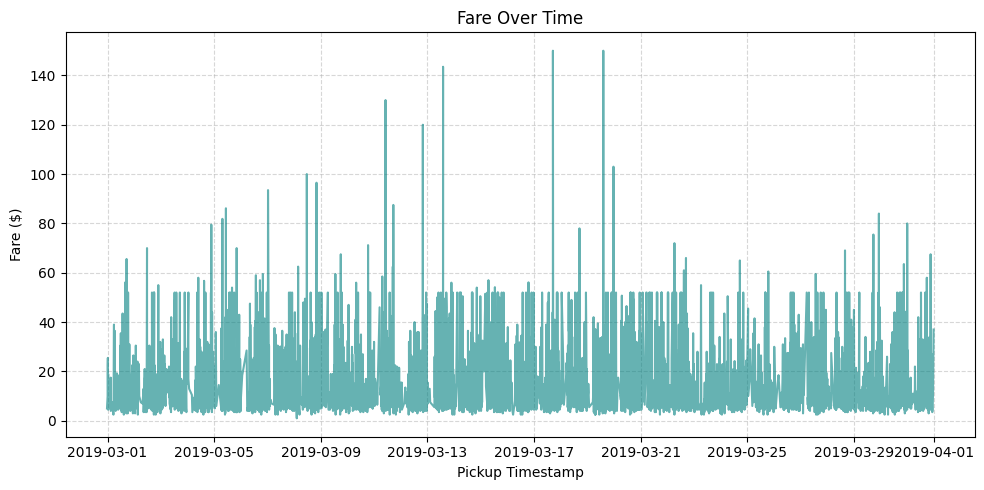

In [48]:
# TASK 3: Visualizations using Matplotlib/Pandas
# Pre-requisite for Line Chart: Convert pickup to datetime and sort
df["pickup"] = pd.to_datetime(df["pickup"])
df_sorted = df.sort_values(by="pickup")

# 1. Line Chart: Fare over time
plt.figure(figsize=(10, 5))
plt.plot(df_sorted["pickup"], df_sorted["fare"], color="teal", alpha=0.6)
plt.title("Fare Over Time")
plt.xlabel("Pickup Timestamp")
plt.ylabel("Fare ($)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

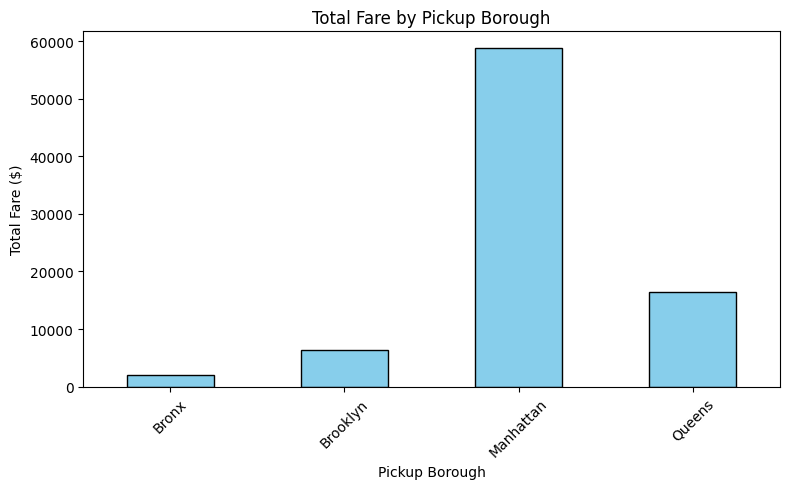

In [39]:
# 2. Bar Chart: Total fare for each pickup_borough
plt.figure(figsize=(8, 5))
borough_fare = df.groupby("pickup_borough")["fare"].sum()
borough_fare.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

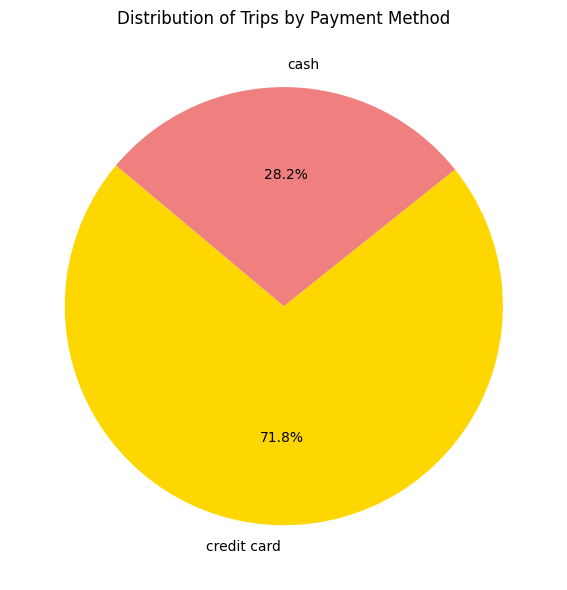

In [40]:
# 3. Pie Chart: Distribution of trips based on payment method
plt.figure(figsize=(6, 6))
payment_counts = df["payment"].value_counts()
payment_counts.plot(
    kind="pie", autopct="%1.1f%%", colors=["gold", "lightcoral"], startangle=140
)
plt.title("Distribution of Trips by Payment Method")
plt.ylabel("")  # Hides the default 'payment' column label on the y-axis
plt.tight_layout()
plt.show()

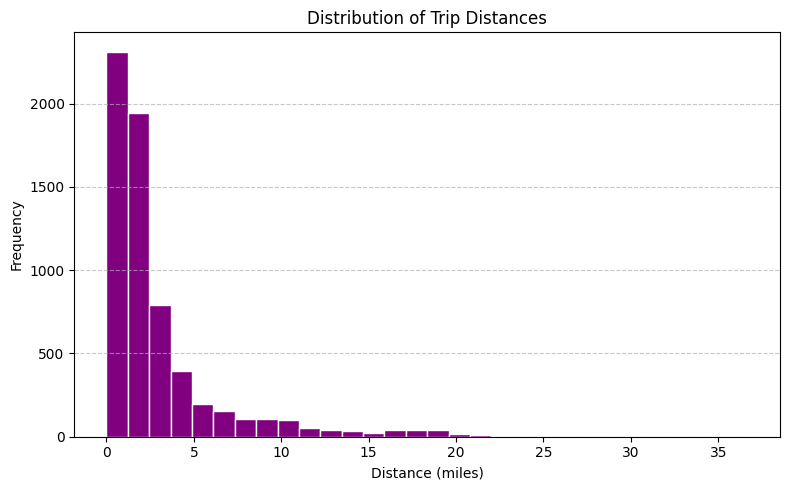

In [41]:
# 4. Histogram: Distribution of distance
plt.figure(figsize=(8, 5))
df["distance"].plot(kind="hist", bins=30, color="purple", edgecolor="white")
plt.title("Distribution of Trip Distances")
plt.xlabel("Distance (miles)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

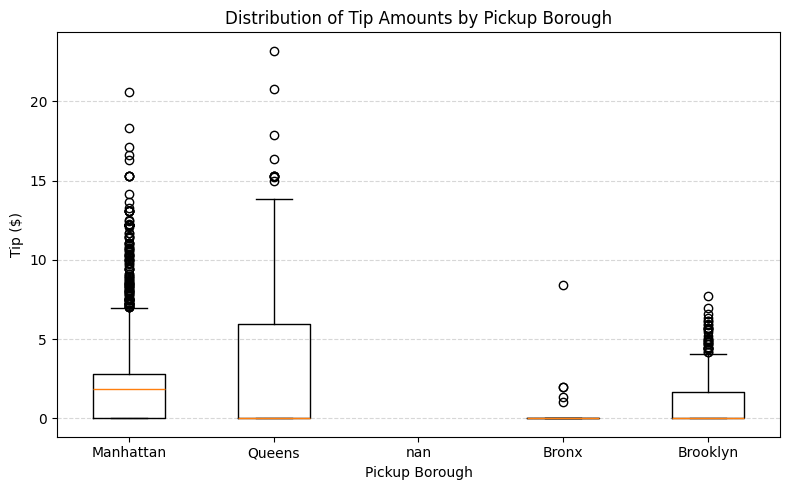

In [42]:
# 5. Box Plot: Distribution of tip amounts for each pickup_borough
plt.figure(figsize=(8, 5))
# Prepare data grouped by borough for standard matplotlib boxplot
boroughs = df["pickup_borough"].unique()
tip_data = [df[df["pickup_borough"] == b]["tip"] for b in boroughs]
plt.boxplot(tip_data, tick_labels=boroughs)
plt.title("Distribution of Tip Amounts by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip ($)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

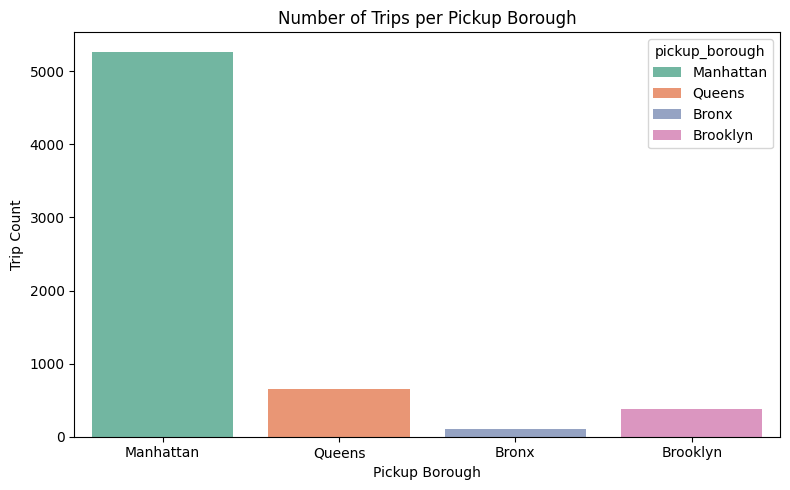

In [43]:
# TASK 4: Visualizations using Seaborn

# 1. Count Plot: Number of trips in each pickup_borough
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="pickup_borough", palette="Set2", hue="pickup_borough")
plt.title("Number of Trips per Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Trip Count")
plt.tight_layout()
plt.show()

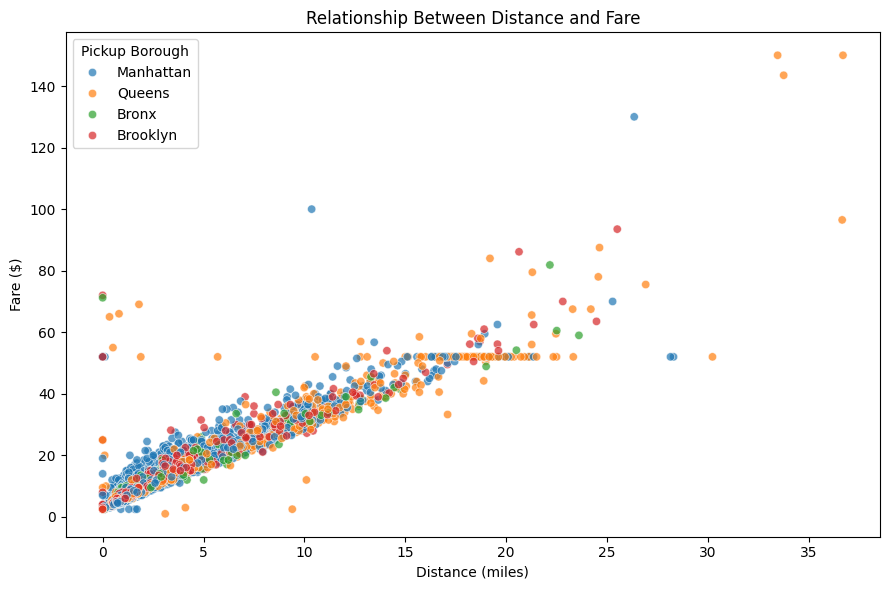

In [44]:
# 2. Scatter Plot: Relationship between distance and fare
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="distance", y="fare", hue="pickup_borough", alpha=0.7)
plt.title("Relationship Between Distance and Fare")
plt.xlabel("Distance (miles)")
plt.ylabel("Fare ($)")
plt.legend(title="Pickup Borough")
plt.tight_layout()
plt.show()

Generating Pair Plot (this may take a few seconds)...


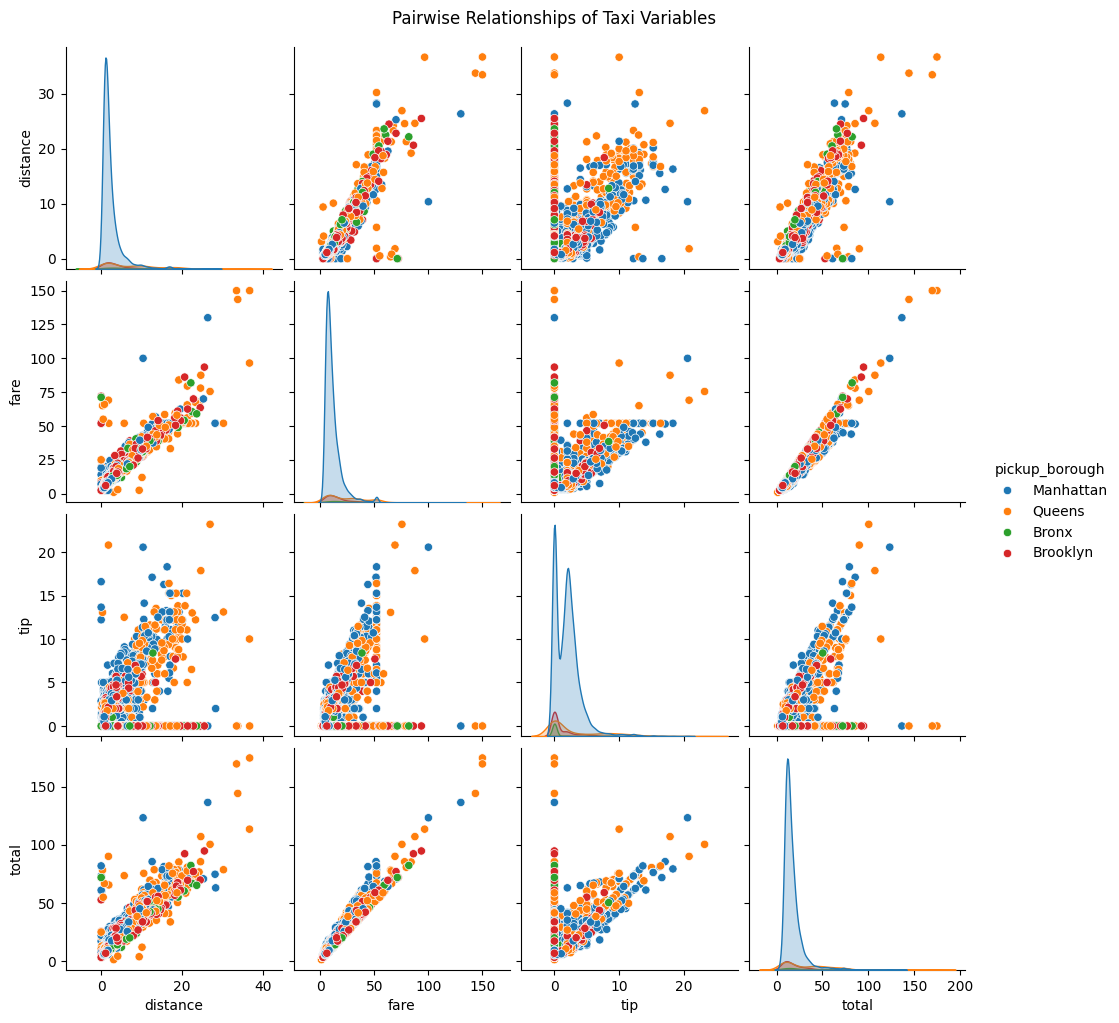

In [45]:
# 4. Pair Plot: Pairwise relationships colored by pickup_borough
# Note: 'pickup_zone' has too many unique values (~100+) to effectively use as a 'hue' color
# in a pairplot, which would freeze your system. Using 'pickup_borough' or limiting data is standard practice here.
print("Generating Pair Plot (this may take a few seconds)...")
sns.pairplot(df, vars=["distance", "fare", "tip", "total"], hue="pickup_borough")
plt.suptitle("Pairwise Relationships of Taxi Variables", y=1.02)
# y adjustments keeps title from overlapping
plt.show()

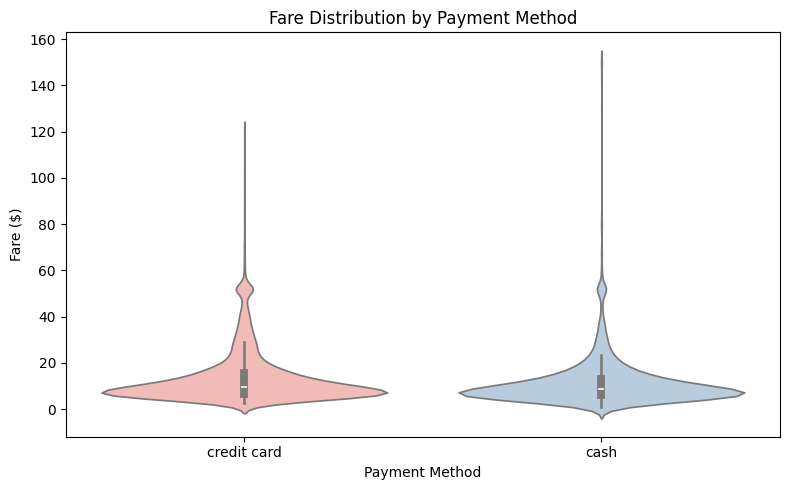


Task completed successfully!


In [50]:
# 5. Violin Plot: Distribution of fare for each payment method
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="payment", y="fare", palette="Pastel1", hue="payment")
plt.title("Fare Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare ($)")
plt.tight_layout()
plt.show()

print("\nTask completed successfully!")